# Regression Exercises

## Linear

In [1]:
# Loading data
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Read data from Github
data_url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/ex1data2.txt"
data_array = np.genfromtxt(data_url, delimiter=',')

# The columns in this data set are define as folows:
"""
    0 = floor area
    1 = number of bedrooms
    2 = sale price
"""

# Store the relevant columns in more descriptive variables
x_sqft = data_array[:,0]
y_value = data_array[:,2]

[link text](https://)Here we'll build off of the tutorial exercise, first finding the best linear fit for floor area (sqft) vs valued price (USD). Recall that setting the derivative = 0 and solving for 𝑏 & 𝑚 produces formula for the best fit trend:
$$ m = \frac{\sum^n_{i=1} (x_i-x_{mean})(y_i-y_{mean})}{\sum^n_{i=1} (x_i-x_{mean})^2} $$
$$ b = y_{mean}-m*x_{mean} $$

In [2]:
def find_best_fit(xx,yy):
    '''
      This function finds the best linear fit for yy vs xx
    '''

    # YOUR CODE HERE

    #calculating the mean
    x_mean = np.mean(xx)
    y_mean = np.mean(yy)

    #calculating the slope
    numerator = np.sum ((xx-x_mean) * (yy-y_mean))
    denominator = np.sum((xx - x_mean) ** 2)
    mm = numerator/denominator

    #calculate the intercept
    bb = y_mean - (mm * x_mean)

    return mm, bb


In [3]:
# Use your function to show the best fit values for our data
(mm,bb) = find_best_fit(x_sqft, y_value)
fit_str = 'y = {aa:.1f}x + {bb:.1f}'
print(fit_str.format(aa=mm,bb=bb))

y = 134.5x + 71270.5


Now we have the best fit trend line that minimizes total error for our data, let's try plotting it and see what it looks like. Since its just an equation, we need to *sample* the curve in order to plot it. To do this, we'll find the difference between the largest and smallest floor area, and divide it into 100 sample points.

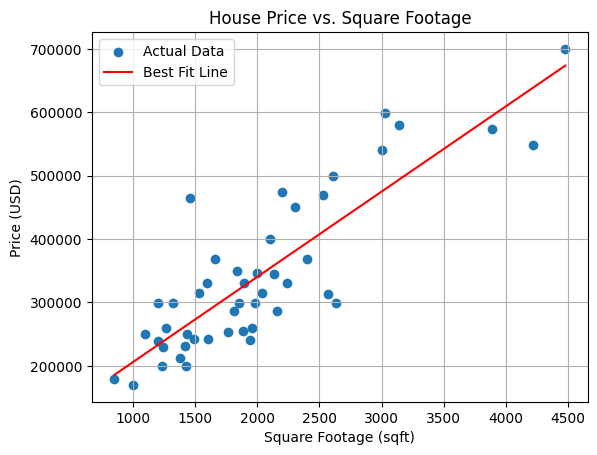

A house with 1600 sqft should cost: $286,510.95
A house with 1600 sqft actually cost: $329,900.00
Money lost: $43,389.05
Percentage of total price: 13.15%


In [4]:
# Plot the data

# Sample the range from minimum to maximum sqft to get 100 points

# Apply the best fit equation to each sample point and plot the result

# To predict, directly use the linear equation y = mx + b
plt.scatter(x_sqft, y_value, label='Actual Data')

x_line = np.linspace(min(x_sqft), max(x_sqft), 100)

y_line = mm * x_line + bb
plt.plot(x_line, y_line, color='red', label='Best Fit Line')

plt.title('House Price vs. Square Footage')
plt.xlabel('Square Footage (sqft)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

predicted_cost = mm * 1600 + bb
print(f"A house with 1600 sqft should cost: ${predicted_cost:,.2f}")
index_1600 = np.where(x_sqft == 1600)[0][0]
actual_cost = y_value[index_1600]
print(f"A house with 1600 sqft actually cost: ${actual_cost:,.2f}")
money_lost = actual_cost - predicted_cost
percent_loss = (money_lost / actual_cost) * 100
print(f"Money lost: ${money_lost:,.2f}")
print(f"Percentage of total price: {percent_loss:.2f}%")

1: Given these parameters, how much should a house with 1600 sqft cost?

A house with 1600 sqft should cost approx. 290k

2: From the dataset, how much did a house with 1600 sqft actually cost?

It actually costed $329900

3: Assuming the current 1600 sqft house would sell for as much as the historical one, how much money would we have lost? What percentage of the total price is this?

$43380.05

Now compare the values for 𝑚 and 𝑏 that sklearn generated in the tutorial notebook with the values that you found just now with your function. Hopefully they match.

In [5]:
print("Sklearn:",134.52528772, 71270.492448729)
print("My function:",mm,bb)

Sklearn: 134.52528772 71270.492448729
My function: 134.52528772024135 71270.49244872906


---
Remember how despite adding an entire new variable, the $R^2$ value barely increased? Let's investigate this further by finding the correlation ($R^2$) value for a regression of square footage vs. number of bedrooms.

In [6]:
import sklearn.linear_model as lm

# YOUR CODE HERE
x_bedrooms = data_array[:, 1].reshape(-1, 1)
y_sqft_target = data_array[:, 0]

#create and fit the linear regression model
corr_model = lm.LinearRegression()
corr_model.fit(x_bedrooms, y_sqft_target)

#.score() method returns the R^2 value
r_squared = corr_model.score(x_bedrooms, y_sqft_target)

print(f"The R-squared value between number of bedrooms and square footage is: {r_squared:.4f}")

The R-squared value between number of bedrooms and square footage is: 0.3136


Do 2 variables have to be verry correlated to reduce their effectiveness together?

(YOUR ANSWER HERE)

## Logistic

We are going to predict wheter or not someone has breast cancer using Logistic Regression on sklearn's breast cancer dataset. It is up to you to decide what features to get the best results.

Feature Columns: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]
Target Column: ['target']


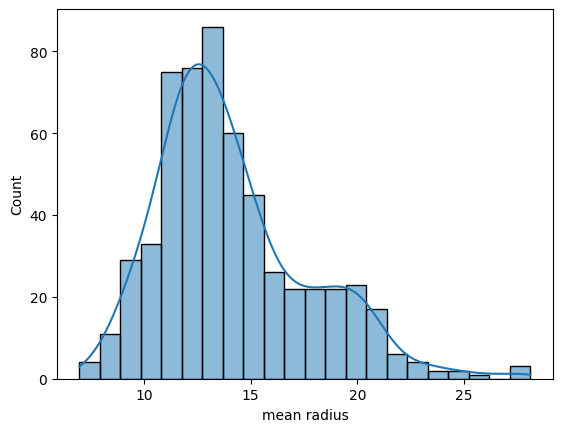

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X_cols = list(data.feature_names)
Y_cols = ['target']

print("Feature Columns:", X_cols)
print("Target Column:", Y_cols)

sns.histplot(df["mean radius"], kde=True)
plt.show()

# splitting the data
X = df[X_cols]
y = df["target"]

test_size = 0.15
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=1)

# defining the model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

Test your logistical regression! You must get an accuracy of > 80%

In [8]:
from sklearn.metrics import accuracy_score

# YOUR CODE HERE
# Printing accuracy of testing & training data
y_train_pred=logreg.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=logreg.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  94.61697722567288
Validation Accuracy is  95.34883720930233
Validation Accuracy is  95.34883720930233
